# Introduction to STARSHIPS Reduction

**STARSHIPS**  
*Spectral Transmission and Radiation Search for High Resolution Planet Signal*

STARSHIPS is a pipeline designed to remove the stellar spectrum signature and residuals from high-resolution time-series data to extract the planetary signal. It generates synthetic sequences and prepares the data for cross-correlation, working order-by-order.

The reduction process consists of several main steps:
1. **Bad Pixel Correction and Masking:** Identify and mask bad pixels in the data.
2. **Spectral Alignment:** Shift each spectrum to align the stellar signal by correcting for barycentric Earth radial velocity (BERV).
3. **Telluric Line Masking:** Identify and mask regions affected by deep telluric absorption.
4. **Reference Spectrum Removal:** Build a master reference spectrum from the aligned spectra and subtract it.
5. **PCA Residual Removal:** Apply principal component analysis (PCA) to remove quasi-static vertical residuals. Typically, multiple numbers of principal components (nPC) are tested.

---

## Working with SPIRou or NIRPS Data

- Data format is typically (number of exposures, number of orders, number of pixels), with >4000 pixels per order.
- Initial calibrations are performed by the **APERO** pipeline.

**APERO** performs:
- Dark correction, bad pixel correction, background subtraction
- Detector nonlinearity correction, order localization, geometric correction
- Flat field correction, blaze correction, hot pixel and cosmic ray removal
- Telluric correction
- Wavelength calibration using the Fabry-Perot etalon method

Reference: [APERO Pipeline Paper](https://iopscience.iop.org/article/10.1088/1538-3873/ac9e74)

APERO produces three main data products:
- **E2DS**: Original extracted spectra
- **TCORR**: Spectra corrected for tellurics
- **RCONN**: Synthetic telluric spectrum

The wavelength solution is handled separately. STARSHIPS will either use the available solution or reconstruct it from the file headers using the `planet_obs.py` functions.

---

## Data Organization and Preprocessing

- APERO outputs are organized by target, not by observation date.
- Observations must be split into individual nights/visits using the "split nights".
- This step sorts by Barycentric Julian Date (BJD) and reduction type, identifying observation gaps.

The sorted observations are saved into files named like:

These files are required for input into STARSHIPS.

Each notebook typically runs one visit reduction at a time.

---

## Adapting STARSHIPS for Other Instruments

STARSHIPS is designed to be flexible:
- Supported instruments currently include SPIRou, NIRPS (APERO and Geneva/ESPRESSO reductions), and IGRINS.
- Modifications to instrument headers can be made inside `planet_obs.py`.



In [1]:
#we are NOT running petitRADTRANS in this tutorial however, starships needs it to run. 
#we are tricking the container here to believe we have petitRADTRANS when infact all the functions are empty

import sys
import types

# Top-level dummy package
petitRADTRANS = types.ModuleType("petitRADTRANS")

# Submodules as separate mock modules/namespaces
petitRADTRANS.Radtrans = object  # or define a dummy class

petitRADTRANS.nat_cst = types.SimpleNamespace()
petitRADTRANS.physics = types.SimpleNamespace(
    guillot_global=lambda *a, **k: None,
    guillot_modif=lambda *a, **k: None
)
petitRADTRANS._read_opacities = types.SimpleNamespace()
petitRADTRANS.fort_input = types.SimpleNamespace()
petitRADTRANS.fort_rebin = types.SimpleNamespace()
petitRADTRANS.pyth_input = types.SimpleNamespace()

poor_mans_nonequ_chem = types.ModuleType("poor_mans_nonequ_chem")
poor_mans_nonequ_chem.interpol_abundances = lambda *a, **k: None

# Register everything in sys.modules
sys.modules["petitRADTRANS"] = petitRADTRANS
sys.modules["petitRADTRANS.radtrans"] = petitRADTRANS
sys.modules["petitRADTRANS._read_opacities"] = petitRADTRANS._read_opacities
sys.modules["petitRADTRANS.fort_input"] = petitRADTRANS.fort_input
sys.modules["petitRADTRANS.fort_rebin"] = petitRADTRANS.fort_rebin
sys.modules["petitRADTRANS.pyth_input"] = petitRADTRANS.pyth_input
sys.modules["petitRADTRANS.nat_cst"] = petitRADTRANS.nat_cst
sys.modules["petitRADTRANS.physics"] = petitRADTRANS.physics
sys.modules["petitRADTRANS.poor_mans_nonequ_chem"] = poor_mans_nonequ_chem

In [2]:
# === System and Path Utilities ===
import os
from sys import path
from pathlib import Path

# === Suppress Warnings ===
import warnings
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)

# === Numerical and Scientific Libraries ===
import numpy as np
import astropy.units as u
import astropy.constants as const

# === Plotting ===
import matplotlib.pyplot as plt

# === STARSHIPS Core Imports ===
import starships.homemade as hm
import starships.planet_obs as pl_obs
import starships.plotting_fcts as pf
from starships import spectrum as spectrum
from starships.planet_obs import Observations
from starships.mask_tools import interp1d_masked

# Disable verbose interpolation output
interp1d_masked.iprint = False


In [3]:
#confirm the path to this notebook within the container
print(os.getcwd())

/home/jovyan/Notebooks


# Lets, set up the planet name and reduction name. This way, we can set up the directory which projects will be stored

In [4]:
#planet name as used in exofile
pl_name = 'WASP-127 b'

#reduction name
reduction = 'ExoSLAM_Workshop'

# Output reductions in dedicated directory
pl_name_fname = ''.join(pl_name.split())  # Remove spaces from the planet name
out_dir = Path(f"{pl_name_fname}_{reduction}")  # Convert to a Path object

# Make sure the  directory exists
out_dir.mkdir(parents=True, exist_ok=True) 
print(out_dir)

WASP-127b_ExoSLAM_Workshop


# Load in the filenames lists that have been previously created in split nights. 
For the purpose of this workshop, we have done this for you

In [5]:
# Make sure the  directory exists
obs_dir = '/home/jovyan/WASP-127data'

# Where to save figures?
path_fig = Path(f"{pl_name_fname}_{reduction}")

In [6]:
list_filenames = {'list_e2ds': 'list_e2ds_2023-03-10-00',
                  'list_tcorr':'list_tcorr_2023-03-10-00'}
print(list_filenames)

{'list_e2ds': 'list_e2ds_2023-03-10-00', 'list_tcorr': 'list_tcorr_2023-03-10-00'}


# Let's Load in the Planet Parameters

At this stage, we need to define the planet parameters.
We can either load them from an existing Exofile or manually reassign them as shown below.
The function used to load the data is Observations, and its inputs are listed below.

The function needed here is observations and the inputes can be as followed

In [7]:
#function being used below
Observations?

Init signature:
Observations(
    wave=array([], dtype=float64),
    count=array([], dtype=float64),
    blaze=array([], dtype=float64),
    headers=[],
    headers_image=[],
    headers_tellu=[],
    tellu=array([], dtype=float64),
    uncorr=array([], dtype=float64),
    name='',
    path='',
    filenames=[],
    planet=None,
    CADC=False,
    pl_kwargs=None,
    instrument='SPIRou-APERO',
)
Docstring:     
Observations class object
Will contain all data and parameters
Note : Probably could be optimized
File:           /usr/local/lib/python3.10/site-packages/starships-1.0.0-py3.10.egg/starships/planet_obs.py
Type:           type
Subclasses:     

In [8]:

# === Planetary and Stellar Parameters that can be changed===
M_star = 0.950 * u.M_sun           # Star mass
R_star = 1.333 * u.R_sun           # Star radius
Teff = 5842 * u.K                  # Star effective temperature

M_pl = 0.165 * u.M_jup             # Planet mass
R_pl = 1.311 * u.R_jup             # Planet radius
Tp = 1400 * u.K                    # Planet temperature

period = 4.178062 * u.day          # Orbital period
trandur = 0.181 * u.day            # Transit duration
ap = 0.04840 * u.au                # Semi-major axis

incl = 87.85 * u.deg               # Orbital inclination
excent = 0.0                       # Eccentricity
w = (-90 * u.deg).to(u.rad)        # Argument of periastron (converted to radians)

#mid transit time does not need to be changed for this data set
# mid_tr = 2460158.66104             # Mid-transit time (BJD_TDB)
# t_peri = 2460158.66104             # Time of periastron passage (same as mid-transit for circular orbit)




# === Create Observation Object from above parameters ===
obs = Observations(
    name=pl_name,
    instrument='NIRPS-APERO',
    pl_kwargs={
        # 'mid_tr': mid_tr,
        # 't_peri': t_peri,
        'excent': excent,
        'w': w,
        'M_star': M_star,
        'R_star': R_star,
        'Teff': Teff,
        'M_pl': M_pl,
        'R_pl': R_pl,
        'Tp': Tp,
        'period': period,
        'trandur': trandur,
        'ap': ap,
        'incl': incl
    }
)



INFO:starships.planet_obs:Getting WASP-127 b from ExoFile
INFO:starships.planet_obs:Changing excent from 0.0 to 0.0
INFO:starships.planet_obs:It became 0.0
INFO:starships.planet_obs:Changing w from [4.71238898] rad to -1.5707963267948966 rad
INFO:starships.planet_obs:It became [-1.57079633] rad
INFO:starships.planet_obs:Changing M_star from [2.14748266e+30] kg to 0.95 solMass
INFO:starships.planet_obs:It became [1.88898938e+30] kg
INFO:starships.planet_obs:Changing R_star from [9.67023e+08] m to 1.333 solRad
INFO:starships.planet_obs:It became [9.273681e+08] m
INFO:starships.planet_obs:Changing Teff from [5620.] K to 5842.0 K
INFO:starships.planet_obs:It became [5842.] K
INFO:starships.planet_obs:Changing M_pl from [3.12621121e+26] kg to 0.165 jupiterMass
INFO:starships.planet_obs:It became [3.13190559e+26] kg
INFO:starships.planet_obs:Changing R_pl from [93726012.] m to 1.311 jupiterRad
INFO:starships.planet_obs:It became [93726012.] m
INFO:starships.planet_obs:Changing Tp from [1400.

In [9]:
#lets re-check those parameters so that we are certain they did indeed change

p = obs.planet

print(p.M_star)
print(p.R_star)
print(p.Teff)

print(p.M_pl)
print(p.R_pl)
print(p.Tp)

print(p.period)
print(p.trandur)
print(p.ap)

print(p.incl)
print(p.excent)
print(p.w)

print(p.mid_tr)
print(p.t_peri)


[1.88898938e+30] kg
[9.273681e+08] m
[5842.] K
[3.13190559e+26] kg
[93726012.] m
[1400.] K
[360984.5568] s
[15638.4] s
[7.24053694e+09] m
[1.53327175] rad
0.0
[-1.57079633] rad
[2458385.175527] d
[2458385.175527] d


# Next we Fetch the observations. We can do this with:  

  def fetch_data(self, path, CADC=False, list_e2ds='list_e2ds',
                    list_tcorr='list_tellu_corrected', list_recon='list_tellu_recon',
                    read_sp=None, **kwargs):
                    
                    
The CADC will mean that this data is being pulled from the Archive

In [10]:
obs.fetch_data?

Signature:
obs.fetch_data(
    path,
    CADC=False,
    list_e2ds='list_e2ds',
    list_tcorr='list_tellu_corrected',
    list_recon='list_tellu_recon',
    read_sp=None,
    **kwargs,
)
Docstring:
Retrieve all the relevent data in path 
(tellu corrected, tellu recon and uncorrected spectra from lists of files)
Georgia Mraz--debugged CADC function on May 22nd 2024
File:      /usr/local/lib/python3.10/site-packages/starships-1.0.0-py3.10.egg/starships/planet_obs.py
Type:      method

In [11]:
obs.fetch_data(obs_dir, CADC=True, **list_filenames)


INFO:starships.planet_obs:Fetching data
INFO:starships.planet_obs:Fetching the uncorrected spectra


# Do a quick sanity chck to make sure all the data is as expected. We can plot it all below

In [12]:
# Extract wave, blaze, and flux data from obs.__dict__
wave = obs.__dict__.get('wave', None)
blaze = obs.__dict__.get('blaze', None)
flux = obs.__dict__.get('count', None)
tellu= obs.__dict__.get('tellu', None)
uncorr= obs.__dict__.get('uncorr', None)


print("shape wave", np.shape(wave))
print("shape blaze",np.shape(blaze))
print("shape, flux", np.shape(flux))

shape wave (56, 75, 4088)
shape blaze (56, 75, 4088)
shape, flux (56, 75, 4088)


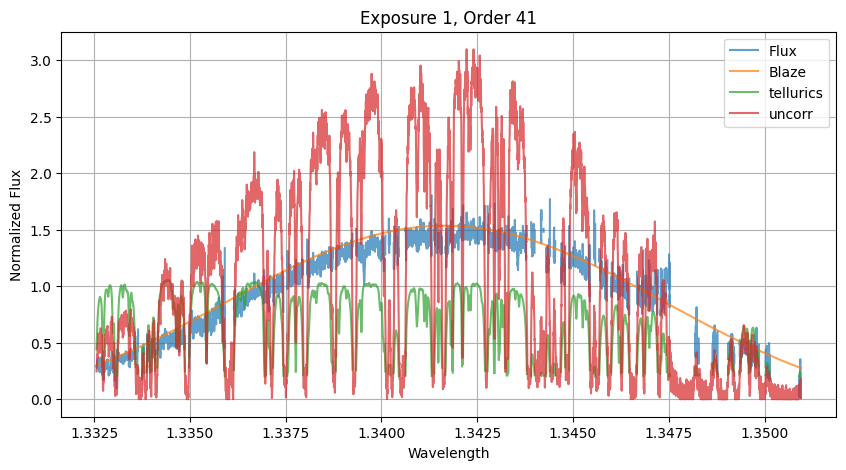

In [13]:
# Select one exposure and one order (e.g., exposure 0 and order 0)
exposure_index = 1
order_index = 41

# Extract the data for the selected exposure and order
selected_wave = wave[exposure_index, order_index]
selected_flux = flux[exposure_index, order_index]
selected_blaze = blaze[exposure_index, order_index]
selected_telluric= tellu[exposure_index, order_index]
selected_uncorr= uncorr[exposure_index, order_index]


# Plot the flux and blaze
plt.figure(figsize=(10, 5))
plt.plot(selected_wave, selected_flux/np.nanmean(selected_flux), label='Flux', alpha=0.7)
plt.plot(selected_wave, selected_blaze/np.nanmean(selected_blaze), label='Blaze', alpha=0.7)
plt.plot(selected_wave, selected_telluric, label='tellurics', alpha=0.7)
plt.plot(selected_wave, selected_uncorr/np.nanmean(selected_uncorr), label='uncorr', alpha=0.7)

#dont normalize telluric spectra

plt.xlabel('Wavelength')
plt.ylabel('Normalized Flux')
plt.title(f'Exposure {exposure_index}, Order {order_index}')
plt.legend()
plt.grid()
plt.show()

## Lets take a look at the reduction functions that will be used below

In [14]:
pl_obs.generate_all_transits?


Signature:
pl_obs.generate_all_transits(
    obs,
    transit_tags,
    RV_sys,
    params_all,
    iOut_temp,
    do_tr=[1, 2, 3, 12, 123],
    cbp=True,
    kind_trans='transmission',
    flux_all=None,
    ld_model='linear',
    coeffs=[0.53],
    polynome=None,
    noise_npc=None,
    counting=True,
    **kwargs_build_ts,
)
Docstring: <no docstring>
File:      /usr/local/lib/python3.10/site-packages/starships-1.0.0-py3.10.egg/starships/planet_obs.py
Type:      function

In [15]:
pl_obs.save_single_sequences?

Signature:
pl_obs.save_single_sequences(
    filename,
    tr,
    path='',
    save_all=False,
    filename_end='',
    bad_indexs=None,
)
Docstring: <no docstring>
File:      /usr/local/lib/python3.10/site-packages/starships-1.0.0-py3.10.egg/starships/planet_obs.py
Type:      function

In [16]:
pl_obs.save_sequences?

Signature:
pl_obs.save_sequences(
    filename,
    list_tr,
    do_tr,
    path='',
    bad_indexs=None,
    save_all=False,
)
Docstring: <no docstring>
File:      /usr/local/lib/python3.10/site-packages/starships-1.0.0-py3.10.egg/starships/planet_obs.py
Type:      function

In [17]:


visit_name = 'WASP127b_TR1_data_trs_' #name your visit, this will be used in the final names
mask_wings = 0.90  # Fraction of telluric wings to mask [typical inputes include 0.90, 0.95, 0.97]

# Radial velocity injection range
n_RV_inj = 151
corrRV0 = np.linspace(-150, 150, n_RV_inj)

# Limb darkening 
coeffs = [0.23081159, 0.2778549]  # Limb-darkening coefficients, can be changed depending on planet
ld_model = 'quadratic'           # Limb-darkening model, can be changed depending on planet

# Correct bad pixels [True, False]
cbp = True

# Type of observation [Transmission, Emission]
kind_trans = 'transmission'      

# System RV [Can be found in Gaia]
RVsys = [-8.9] 

#to remove any exposures replace None with array ex:[1,5,8]
transit_tags = [None]

#PARAMETERS IDK HOW TO EXPLAIN
iout_all = ['all']
polynome = [False] 

#only used if doing multiple reductions at a time-> if not keep fixed
do_tr = [1]

# Transit generation kwargs
kwargs_gen_tr = {
    'coeffs': coeffs,
    'ld_model': ld_model,
    'do_tr': do_tr,
    'kind_trans': kind_trans,
    'polynome': polynome,
    'cbp': cbp
}

# Timeseries construction kwargs
kwargs_build_ts = {
    'clip_ratio': 6, # PARAMETERS IDK HOW TO EXPLAIN
    'clip_ts': 6, # PARAMETERS IDK HOW TO EXPLAIN
    'unberv_it': True #would you like to do the berv correction[True,False]

}

######################################################################################################################################
# Loop over number of principal components to remove

for n_pc in range(2, 3):
    # Additional parameters used for data reduction:
    telluric_mask_frac = 0.20        # Fraction of deep tellurics to mask typical inputes [0.2,0.5]
    smoothing_width = 51             # Width of smoothing kernel (fixed)
    dummy_param = 41                 # dummy parameter (ignored internally)
    gaussian_width = 5               # Gaussian kernel width for filtering (fixed)
    sigma_clip = 5.0                 # Sigma clipping threshold (fixed)

    # Combine all into param structure used by function
    params_all = [[
        telluric_mask_frac,    # [0]- Telluric fraction to mask
        mask_wings,            # [1] - Mask wings limit
        smoothing_width,       # [2] - Low-pass smoothing width
        dummy_param,           # [3] - Ignored
        gaussian_width,        # [4] - Gaussian kernel width
        n_pc,                  # [5] - Number of principal components to remove
        sigma_clip, sigma_clip, sigma_clip, sigma_clip  # [6-9] - Clipping parameters
    ]]

    # Generate transit sequences
    list_tr = pl_obs.generate_all_transits(
        obs, transit_tags, RVsys, params_all, iout_all,
        **kwargs_gen_tr, **kwargs_build_ts
    )

    # Save full transit sequence
    out_filename = f'sequence_{n_pc}-pc_mask_wings{int(mask_wings*100)}'
    pl_obs.save_single_sequences(out_filename, list_tr['1'], path=out_dir, filename_end=visit_name,save_all=True)

    # Save simplified version for retrieval use
    out_filename = f'retrieval_input_{n_pc}-pc_mask_wings{int(mask_wings*100)}'
    pl_obs.save_sequences(out_filename, list_tr, do_tr, path=out_dir,save_all=True)

([24.849062659052564, 27.99953869919666, 29.297234379213204, 31.06001188522617, 31.338887905462506, 33.00050991412605, 30.18847980561956, 32.41436505822661, 33.755697384981715, 34.04209489716489, 34.49658645976708, 35.62738743438895, 37.53978481234577, 35.95124366095284, 35.49402134469472, 36.04851862147545, 35.92679995065626, 33.60319672672818, 36.987949718328075, 38.6249431486367, 39.74038134546395, 38.80752514686962, 38.39649677781024, 38.03252919542737, 39.74211822562583, 40.5320063881224, 39.54158343160715, 40.086316331536416, 40.12724416828668, 40.38298270105469, 39.15369540007928, 36.956185431368546, 38.47425684721061, 38.68992621570957, 38.80966051855554, 36.96791539438837, 36.49582449829681, 38.50844065450632, 39.28529347999979, 39.5624002452701, 38.65578275795109, 36.37236061799619, 36.01515928010953, 32.81070337335553, 34.99530860011731, 35.65109020700918, 36.8933017606609, 36.56025849391067, 35.88756410074299, 34.411380600997035, 35.174147226684475, 35.502047657659126, 34.8

/usr/local/lib/python3.10/site-packages/scikit_learn-1.3.1-py3.10-linux-x86_64.egg/sklearn/utils/deprecation.py:101: FutureWarning: Attribute `n_features_` was deprecated in version 1.2 and will be removed in 1.4. Use `n_features_in_` instead.
  warnings.warn(msg, category=FutureWarning)


WASP-127b_ExoSLAM_Workshop/retrieval_input_2-pc_mask_wings90_data_info.npz
WASP-127b_ExoSLAM_Workshop/retrieval_input_2-pc_mask_wings90_data_trs_0.npz


# Thats it! now lets see what we did

This can now be loaded in another notebook as well. Here we are analyzing the output of our reductions files that were created above and then stored.


In [18]:
#this will plot the summary of mean SNR and airmass for the night
#in the plot red=out of transit, blue= in transit and green=ingress/egress
pl_obs.load_single_sequences?

Signature:
pl_obs.load_single_sequences(
    filename,
    name,
    path='',
    load_all=False,
    filename_end='',
    plot=True,
    **kwargs,
)
Docstring: <no docstring>
File:      /usr/local/lib/python3.10/site-packages/starships-1.0.0-py3.10.egg/starships/planet_obs.py
Type:      function

Transmission


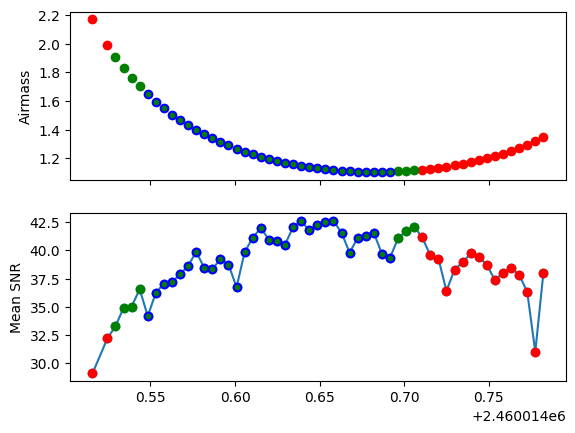

In [19]:
pl_obs.load_single_sequences('sequence_2-pc_mask_wings90_data_trs_WASP127b_TR1',
                             name=pl_name, planet=p, path=out_dir)


In [20]:

pf.plot_steps?

Signature:
pf.plot_steps(
    tr,
    iord,
    xlim=None,
    masking_limit=None,
    id_spec=0,
    fig_name='',
    cmap=None,
    bad_color='red',
    path_fig=None,
)
Docstring: <no docstring>
File:      /usr/local/lib/python3.10/site-packages/starships-1.0.0-py3.10.egg/starships/plotting_fcts.py
Type:      function

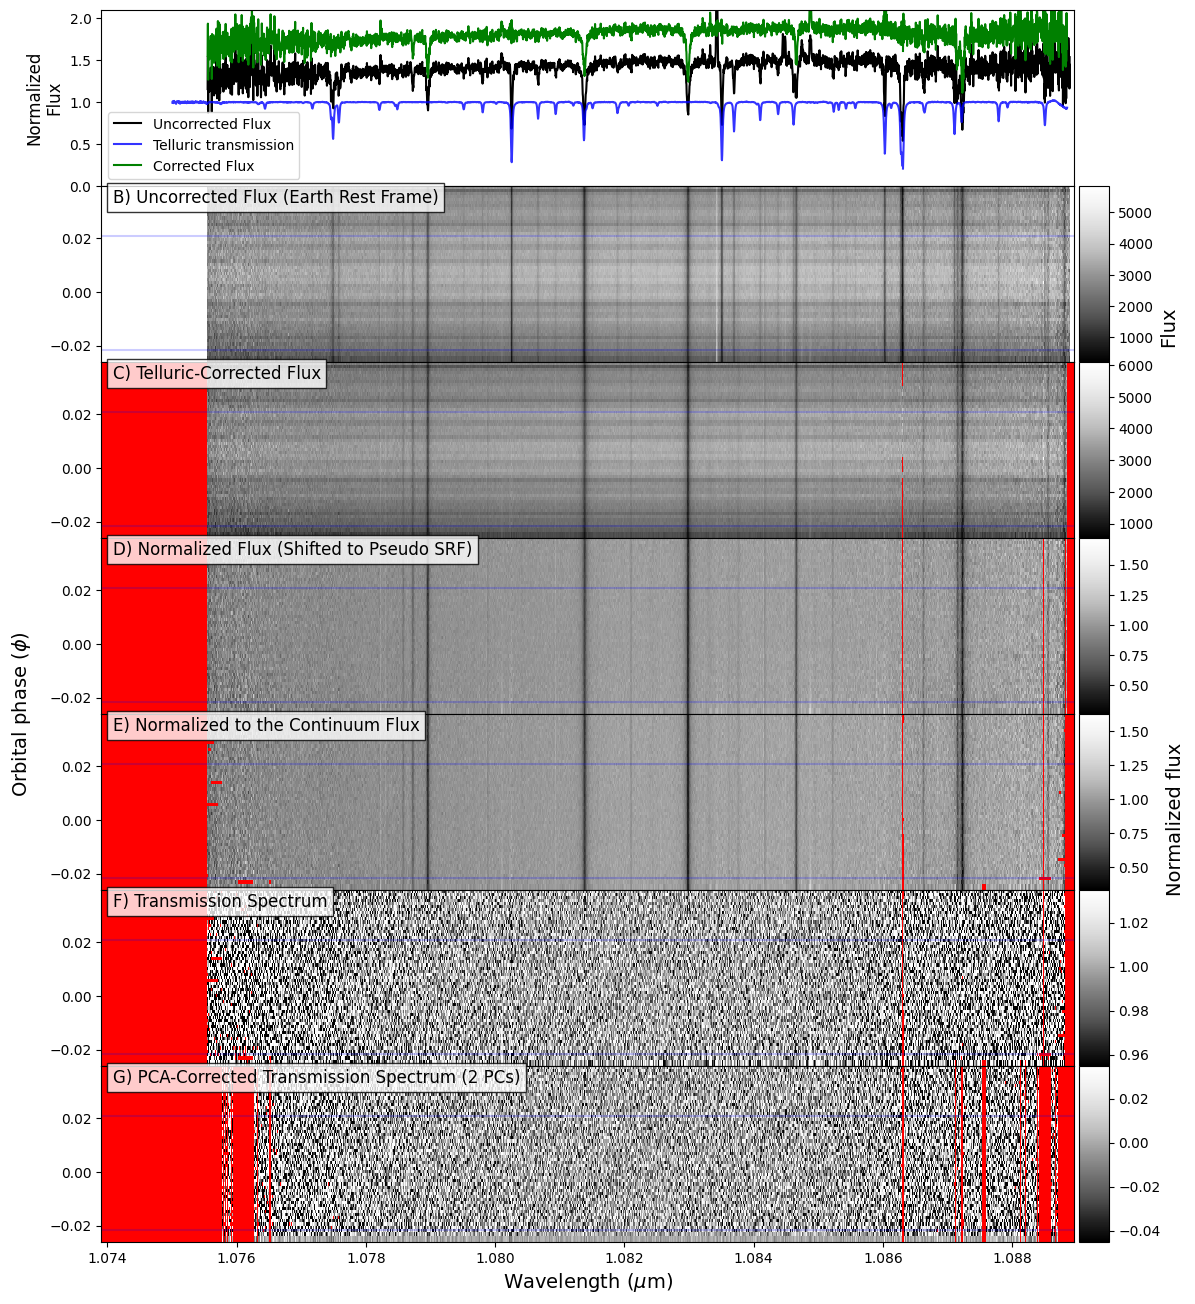

In [21]:
pf.plot_steps(list_tr['1'], 15)
